# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Waqas Ahmed)_

**Roll Number:** _(023-24-0031)_

**GitHub Repository:** _([link, added before submission](https://github.com/waqas309/ML-Lab-Lab02))_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV as one raw column
raw = pd.read_csv("telco_churn.csv", header=None)

# Split the comma-separated data into separate columns
df = raw[0].str.split(",", expand=True)

# Use first row as column names
df.columns = df.iloc[0]

# Remove header row from data
df = df.iloc[1:].reset_index(drop=True)

# Remove possible whitespace from column names
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
0  customerID  gender SeniorCitizen Partner Dependents tenure PhoneService  \
0  7590-VHVEG  Female             0     Yes         No      1           No   
1  5575-GNVDE    Male             0      No         No     34          Yes   
2  3668-QPYBK    Male             0      No         No      2          Yes   
3  7795-CFOCW    Male             0      No         No     45           No   
4  9237-HQITU  Female             0      No         No      2          Yes   

0     MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

0 TechSupport StreamingTV StreamingMovies        Contrac

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [7]:
# Task 4 — dataset shape, column names, data types
print("Shape:", df.shape)
print(df.columns.tolist())
print(df.dtypes)

Shape: (7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
0
customerID          str
gender              str
SeniorCitizen       str
Partner             str
Dependents          str
tenure              str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
MonthlyCharges      str
TotalCharges        str
Churn               str
dtype: object


In [8]:
# Task 5 — identify identifier columns / wrong data types
print("Data types:")
print(df.dtypes)

print("\nIdentifier column:")
print("customerID")

print("\nUnique customer IDs:", df["customerID"].nunique())

print("\nNumerical columns:")
print(["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"])

print("\nPotential data-type issue:")
print("TotalCharges is stored as object/string but represents a numerical monetary amount.")

Data types:
0
customerID          str
gender              str
SeniorCitizen       str
Partner             str
Dependents          str
tenure              str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
MonthlyCharges      str
TotalCharges        str
Churn               str
dtype: object

Identifier column:
customerID

Unique customer IDs: 7043

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Potential data-type issue:
TotalCharges is stored as object/string but represents a numerical monetary amount.


In [9]:
# Task 6 — unique values in 3 categorical columns
columns = ["gender", "Contract", "InternetService"]

for col in columns:
    print(f"\n{col}:")
    print(df[col].unique())
    print("Number of unique values:", df[col].nunique())


gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
Number of unique values: 2

Contract:
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
Number of unique values: 3

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Number of unique values: 3


**Observations (Part 2):**
_(The dataset contains 7,043 customer records and 21 columns. customerID is an identifier rather than a predictive feature and should be removed before modeling. The numerical features are SeniorCitizen, tenure, MonthlyCharges, and TotalCharges, while the remaining columns are categorical. TotalCharges is stored as text even though it represents a numerical monetary amount, so it requires conversion.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [10]:
# Task 7 — missing values: count and percentage per column
total_charges_check = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)

missing_count = total_charges_check.isnull().sum()
missing_percentage = total_charges_check.isnull().mean() * 100

print("TotalCharges missing/blank count:", missing_count)
print("TotalCharges missing/blank percentage:", round(missing_percentage, 2), "%")

print("\nMissing/blank values by column:")
missing_report = pd.DataFrame({
    "Missing Count": [total_charges_check.isnull().sum()],
    "Missing Percentage": [total_charges_check.isnull().mean() * 100]
}, index=["TotalCharges"])

print(missing_report)

TotalCharges missing/blank count: 11
TotalCharges missing/blank percentage: 0.16 %

Missing/blank values by column:
              Missing Count  Missing Percentage
TotalCharges             11            0.156183


In [11]:
# Task 8 — duplicate rows vs duplicate IDs

duplicate_rows = df.duplicated().sum()
duplicate_ids = df["customerID"].duplicated().sum()

print("Duplicate complete rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_ids)

Duplicate complete rows: 0
Duplicate customer IDs: 0


In [12]:
# Task 9 — investigate a suspicious / invalid value
# Investigate suspicious values in TotalCharges
blank_totalcharges = df[df["TotalCharges"].str.strip() == ""]

print("Number of blank TotalCharges values:", len(blank_totalcharges))

print("\nRows with blank TotalCharges:")
print(blank_totalcharges[["customerID", "tenure", "TotalCharges", "Churn"]])

print("\nTenure values for these customers:")
print(blank_totalcharges["tenure"].value_counts())

Number of blank TotalCharges values: 11

Rows with blank TotalCharges:
0     customerID tenure TotalCharges Churn
488   4472-LVYGI      0                 No
753   3115-CZMZD      0                 No
936   5709-LVOEQ      0                 No
1082  4367-NUYAO      0                 No
1340  1371-DWPAZ      0                 No
3331  7644-OMVMY      0                 No
3826  3213-VVOLG      0                 No
4380  2520-SGTTA      0                 No
5218  2923-ARZLG      0                 No
6670  4075-WKNIU      0                 No
6754  2775-SEFEE      0                 No

Tenure values for these customers:
tenure
0    11
Name: count, dtype: int64


**Answer 7 (which missing-value problems need action, and why):**
The dataset contains 11 blank values in TotalCharges, representing approximately 0.16% of the 7,043 customers. These values require action because TotalCharges is a numerical feature needed for analysis. The blank values occur for customers with tenure equal to 0, so treating them as 0 is reasonable because these customers have not accumulated any tenure-based charges.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
There are 0 completely duplicated rows and 0 duplicated customer IDs in the raw dataset. Duplicate rows and duplicate IDs are different issues: a duplicate row means the entire record is repeated, while a duplicate ID means the same customer identifier appears more than once.

**Answer 9 (suspicious value found and how):**
A suspicious value was found in TotalCharges. The column represents a numerical monetary amount but is stored as text, and 11 records contain blank strings. These records have tenure equal to 0, so the blank TotalCharges values can reasonably be interpreted as zero.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| TotalCharges stored as text|Convert to numeric | pd.to_numeric() | It represents a monetary amount and should be numeric for analysis/modeling.|
| Missing values |No action required | df.isnull().sum() | No missing values were found in the dataset. |
| Duplicate rows| Remove only if found | df.drop_duplicates() | Duplicate records can bias analysis and modeling. |     

In [13]:
# Task 11 — apply your cleaning decisions here
cleaned_df = df.copy()

# 1. Remove whitespace from column names
cleaned_df.columns = cleaned_df.columns.str.strip()

# 2. Convert numerical columns
cleaned_df["SeniorCitizen"] = pd.to_numeric(
    cleaned_df["SeniorCitizen"],
    errors="coerce"
)

cleaned_df["tenure"] = pd.to_numeric(
    cleaned_df["tenure"],
    errors="coerce"
)

cleaned_df["MonthlyCharges"] = pd.to_numeric(
    cleaned_df["MonthlyCharges"],
    errors="coerce"
)

# 3. Convert blank TotalCharges to NaN
cleaned_df["TotalCharges"] = cleaned_df["TotalCharges"].replace(
    r"^\s*$", np.nan, regex=True
)

# 4. Convert TotalCharges to numeric
cleaned_df["TotalCharges"] = pd.to_numeric(
    cleaned_df["TotalCharges"],
    errors="coerce"
)

# 5. Fill missing TotalCharges with 0
cleaned_df["TotalCharges"] = cleaned_df["TotalCharges"].fillna(0)

print("After handling missing values:")
print(cleaned_df.shape)

# 6. Remove customerID
cleaned_df = cleaned_df.drop(columns=["customerID"])

# 7. Remove duplicate feature rows
print("Duplicate rows before removal:", cleaned_df.duplicated().sum())

cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

print("Final intermediate shape:", cleaned_df.shape)

After handling missing values:
(7043, 21)
Duplicate rows before removal: 22
Final intermediate shape: (7021, 20)


In [15]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values:")
print(cleaned_df.isnull().sum())

print("\nTotal missing values:",
      cleaned_df.isnull().sum().sum())

print("\nDuplicate rows:",
      cleaned_df.duplicated().sum())

print("\nData types:")
print(cleaned_df.dtypes)

print("\nShape:")
print(cleaned_df.shape)

Missing values:
0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Data types:
0
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod         

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

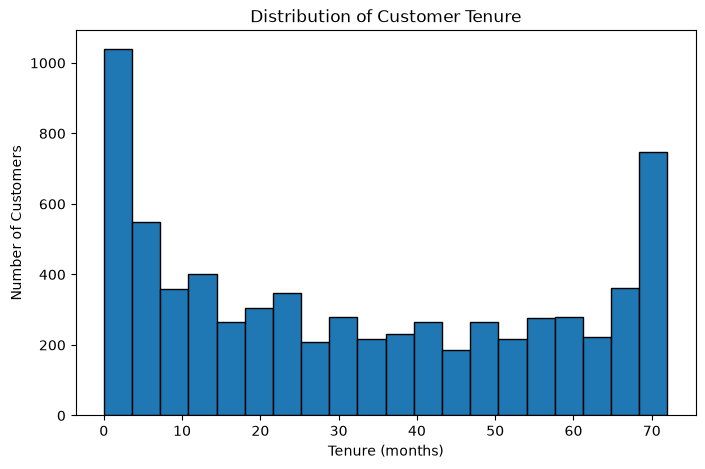

In [16]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize=(8, 5))

plt.hist(cleaned_df["tenure"], bins=20, edgecolor="black")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _(Customer tenure ranges from 0 to 72 months. The distribution is spread across the full range, with many customers having relatively short tenures and another noticeable concentration among long-term customers.)_

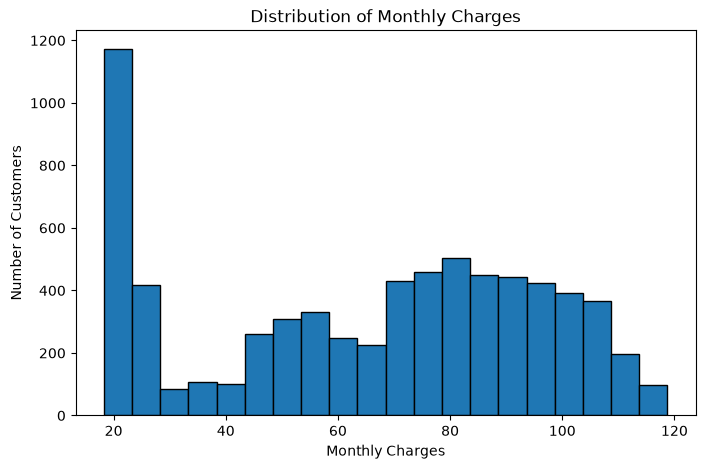

In [17]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["MonthlyCharges"], bins=20, edgecolor="black")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _(Monthly charges range from about $18 to $119, with many customers concentrated around the middle-to-higher charge range. The distribution is fairly balanced overall, although there are some variations in customer pricing.)_

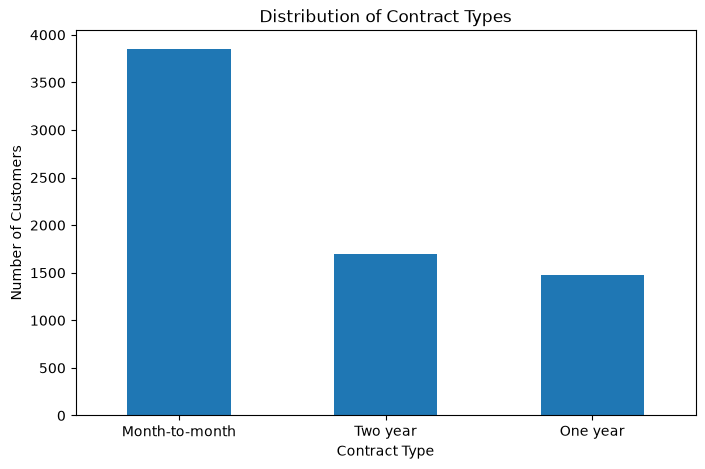

In [18]:
# Task 12 — categorical feature 1: distribution plot
contract_counts = cleaned_df["Contract"].value_counts()
plt.figure(figsize=(8, 5))
contract_counts.plot(kind="bar")
plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Observation:** _(Month-to-month contracts are the most common, with 3,875 customers, while one-year and two-year contracts have fewer customers. This shows that the dataset contains substantially more customers on flexible month-to-month contracts.)_

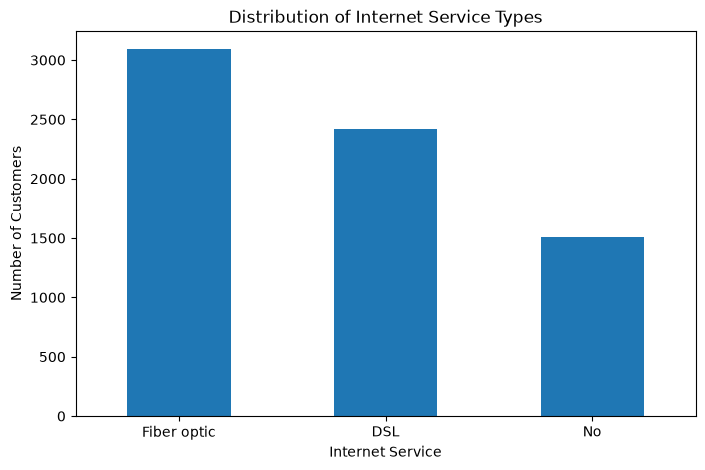

In [19]:
# Task 12 — categorical feature 2: distribution plot
internet_counts = cleaned_df["InternetService"].value_counts()
plt.figure(figsize=(8, 5))
internet_counts.plot(kind="bar")
plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Observation:** _(Fiber optic is the most common internet service with 3,096 customers, followed by DSL with 2,421 customers. A smaller group of 1,526 customers does not use an internet service.)_

**Answer 13 (outliers / skew and possible explanation):**
_(The tenure and MonthlyCharges distributions are relatively close to symmetric and do not show strong skewness. TotalCharges is more right-skewed, which is reasonable because customers who have stayed with the company longer can accumulate much larger total charges. The numerical variables do not show major extreme outliers based on the IQR check.e)_

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [20]:
# Task 14 — churn counts and percentages
churn_counts = cleaned_df["Churn"].value_counts()
churn_percentages = cleaned_df["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(churn_percentages.round(2))

Churn counts:
Churn
No     5164
Yes    1857
Name: count, dtype: int64

Churn percentages:
Churn
No     73.55
Yes    26.45
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_(The target variable is imbalanced. Approximately 73% of customers did not churn, while about 27% churned. Therefore, the two classes are not evenly represented.)_

**Answer 15 (why imbalance might matter later):**
_(Class imbalance matters because a classification model may perform well on the majority class while performing poorly on the minority class. In this dataset, a model could appear accurate by mostly predicting non-churn, while failing to correctly identify customers who actually churn.)_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn percentage by contract type:
Churn              No    Yes
Contract                    
Month-to-month  57.36  42.64
One year        88.73  11.27
Two year        97.17   2.83


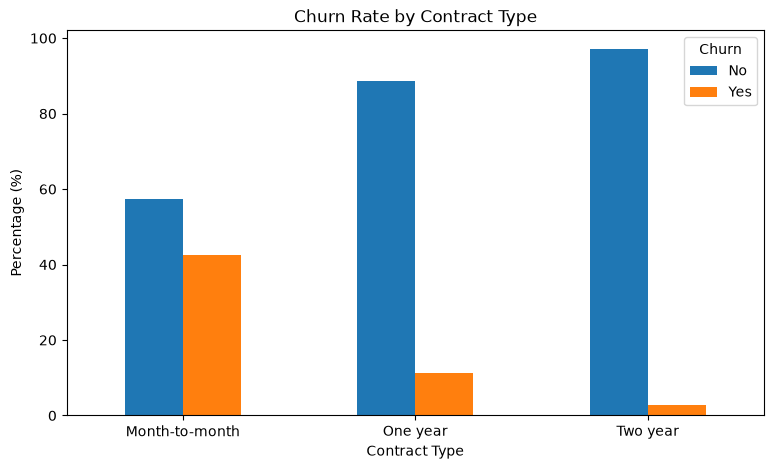

In [21]:
# Task 16 — categorical feature 1 vs Churn
contract_churn = pd.crosstab(
    cleaned_df["Contract"],
    cleaned_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by contract type:")
print(contract_churn.round(2))

# Plot
contract_churn.plot(kind="bar", figsize=(9, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

**Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.:** _..._
**Approximately 42.7% of month-to-month customers churned, compared with about 11.3% of one-year customers and 2.8% of two-year customers.:** _..._
**Month-to-month customers have greater flexibility to leave because they are not committed to a long-term contract. Longer contracts may encourage customers to remain with the company.:** _..._

Churn percentage by internet service:
Churn               No    Yes
InternetService              
DSL              81.11  18.89
Fiber optic      58.22  41.78
No               92.79   7.21


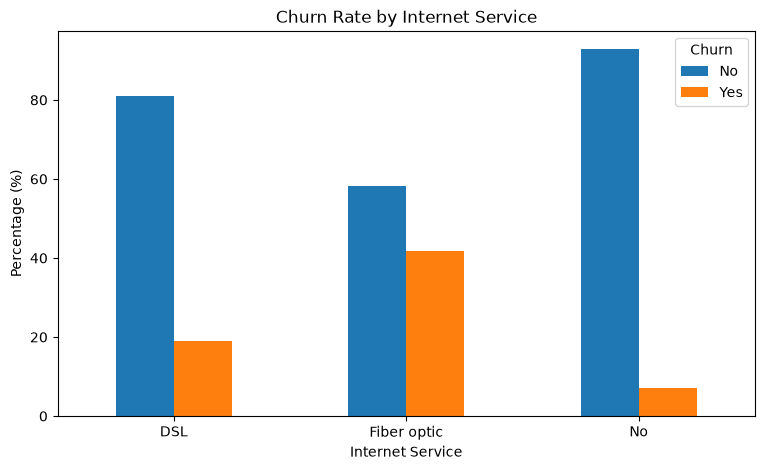

In [22]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(
    cleaned_df["InternetService"],
    cleaned_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by internet service:")
print(internet_churn.round(2))

# Plot
internet_churn.plot(kind="bar", figsize=(9, 5))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

**Customers using fiber optic internet have a substantially higher churn rate than customers using DSL or no internet service.:** _..._
**The churn rate is approximately 41.9% for fiber-optic customers, compared with about 19.0% for DSL customers and 7.4% for customers without internet service.:** _..._
**The higher churn among fiber-optic customers may be related to service expectations, pricing, competition, or customer dissatisfaction. However, this analysis shows an association and does not prove that fiber service itself causes churn.:** _..._

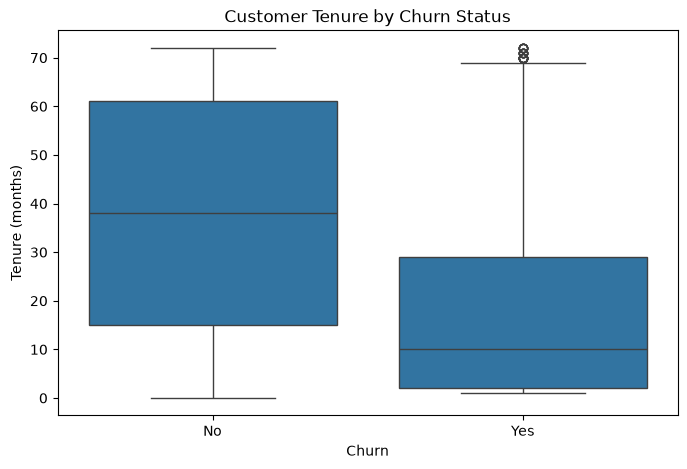

Tenure statistics by churn:
       count   mean  median  min  max
Churn                                
No      5164  37.64    38.0    0   72
Yes     1857  18.09    10.0    1   72


In [23]:
# Task 17 — numerical feature 1 vs Churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=cleaned_df
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")

plt.show()

# Summary statistics
print("Tenure statistics by churn:")
print(
    cleaned_df.groupby("Churn")["tenure"].agg(["count", "mean", "median", "min", "max"]).round(2)
)

**Customers who churn generally have shorter tenures than customers who remain with the company.:** _..._
**The average tenure of customers who churn is approximately 18 months, compared with about 38 months for customers who do not churn.:** _..._
**Newer customers may have weaker long-term relationships with the company and may be more willing to switch to another provider.:** _..._

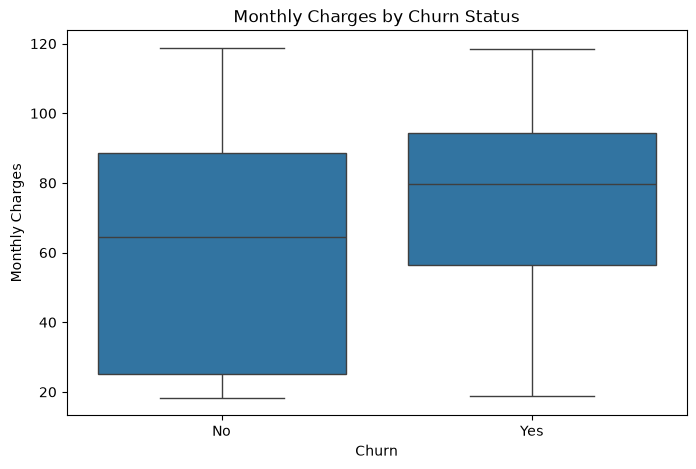

Monthly charges statistics by churn:
       count   mean  median    min     max
Churn                                     
No      5164  61.34    64.5  18.25  118.75
Yes     1857  74.60    79.7  18.85  118.35


In [24]:
# Task 17 — numerical feature 2 vs Churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=cleaned_df
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

# Summary statistics
print("Monthly charges statistics by churn:")
print(cleaned_df.groupby("Churn")["MonthlyCharges"].agg(["count", "mean", "median", "min", "max"]).round(2))

**Observation: Customers who churn tend to have higher monthly charges than customers who remain.:** _..._
**Evidence: The average monthly charge is approximately $74 for customers who churn, compared with about $61 for customers who do not churn.:** _..._
**Possible Explanation: Higher monthly charges may make customers more sensitive to pricing or more likely to consider competing services. However, the relationship may also be influenced by other factors such as contract type and internet service.:** _..._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

Correlation Matrix:
0               SeniorCitizen  tenure  MonthlyCharges  TotalCharges
0                                                                  
SeniorCitizen            1.00    0.02            0.22          0.10
tenure                   0.02    1.00            0.25          0.83
MonthlyCharges           0.22    0.25            1.00          0.65
TotalCharges             0.10    0.83            0.65          1.00


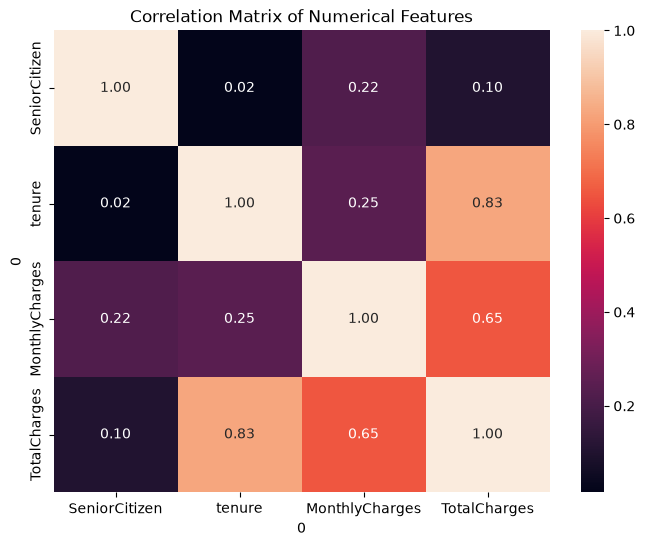

In [25]:
# Task 18 — correlation matrix and heatmap
numeric_df = cleaned_df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
]

corr_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(corr_matrix.round(2))

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Answer 18 (most correlated pairs):**
_(The strongest correlation appears between tenure and TotalCharges, because customers who stay longer generally accumulate higher total charges. MonthlyCharges and TotalCharges also show a positive relationship, while the other numerical feature relationships are weaker.)_

**Answer 19 (correlation vs. causation; potential problems):**
_(Correlation does not imply causation; two variables can be related without one directly causing the other. Highly correlated features can cause redundancy in a future model and may make the model coefficients or feature importance harder to interpret.)_

**Answer 1:**
The telecommunications company wants to identify customers who are likely to leave for a competitor so it can take action to retain them. The likely target variable is Churn, which indicates whether a customer left the company or stayed.

**Answer 2:**
Useful predictors:
Tenure — Customers with shorter or longer relationships may have different churn risks.
MonthlyCharges — High monthly charges may increase the chance of customers leaving.
Contract — Customers with month-to-month contracts may be more likely to churn.
InternetService — The type of internet service may influence customer satisfaction and churn.
PaymentMethod — Different payment methods may be associated with different churn patterns.
Likely useless predictors:
CustomerID — It is only an identifier and does not provide meaningful information about churn.

**Answer 3:**
Are customers with month-to-month contracts more likely to churn than customers with long-term contracts?
Do customers with higher monthly charges have a higher churn rate?

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(customerID is a suspect column because it is a unique identifier rather than a meaningful customer characteristic. It should not be used as a predictive feature because it does not provide useful information about why a customer may churn. The other columns in the dataset describe customer information or services that could reasonably be available before prediction.e)_

**Answer 21 (what would go wrong):**
_(Including an identifier such as customerID could cause the model to learn meaningless patterns instead of genuine relationships with churn. If a feature contained information only available after churn, it would create data leakage and make the model appear artificially accurate while performing poorly on real future customers.)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique identifier; does not provide useful predictive information. |
| gender | Categorical | Feature | Keep + Encode | Customer demographic category that can be used as a feature. |
| SeniorCitizen | Categorical/Binary | Feature | Keep + Encode | Indicates whether the customer is a senior citizen. |
| Partner | Categorical | Feature | Keep + Encode | Describes whether the customer has a partner. |
| Dependents | Categorical | Feature | Keep + Encode | Describes whether the customer has dependents. |
| tenure | Numerical | Feature | Keep | Number of months the customer has stayed with the company. |
| PhoneService | Categorical | Feature | Keep + Encode | Indicates whether the customer has phone service. |
| MultipleLines | Categorical | Feature | Keep + Encode | Describes the customer's multiple-line service status. |
| InternetService | Categorical | Feature | Keep + Encode | Describes the customer's internet service type. |
| OnlineSecurity | Categorical | Feature | Keep + Encode | Describes whether the customer has online security service. |
| OnlineBackup | Categorical | Feature | Keep + Encode | Describes whether the customer has online backup service. |
| DeviceProtection | Categorical | Feature | Keep + Encode | Describes whether the customer has device protection. |
| TechSupport | Categorical | Feature | Keep + Encode | Describes whether the customer has technical support. |
| StreamingTV | Categorical | Feature | Keep + Encode | Describes whether the customer has streaming TV service. |
| StreamingMovies | Categorical | Feature | Keep + Encode | Describes whether the customer has streaming movie service. |
| Contract | Categorical | Feature | Keep + Encode | Contract type is strongly associated with churn. |
| PaperlessBilling | Categorical | Feature | Keep + Encode | Indicates the customer's billing method. |
| PaymentMethod | Categorical | Feature | Keep + Encode | Describes how the customer pays for the service. |
| MonthlyCharges | Numerical | Feature | Keep | Represents the customer's monthly service charges. |
| TotalCharges | Numerical | Feature | Keep | Represents total charges accumulated by the customer; missing values were handled during cleaning. |
| Churn | Categorical | Target | Keep | This is the variable the future classification model will predict. |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [26]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Remove whitespace from column names
clean_df.columns = clean_df.columns.str.strip()

# Convert numerical columns
clean_df["SeniorCitizen"] = pd.to_numeric(
    clean_df["SeniorCitizen"],
    errors="coerce"
)

clean_df["tenure"] = pd.to_numeric(
    clean_df["tenure"],
    errors="coerce"
)

clean_df["MonthlyCharges"] = pd.to_numeric(
    clean_df["MonthlyCharges"],
    errors="coerce"
)

# Convert blank TotalCharges values to NaN
clean_df["TotalCharges"] = clean_df["TotalCharges"].replace(
    r"^\s*$", np.nan, regex=True
)

# Convert TotalCharges to numeric
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

# Fill blank TotalCharges with 0
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)

print("Rows before duplicate removal:", len(clean_df))

# Remove identifier
clean_df = clean_df.drop(columns=["customerID"])

print("Duplicate rows before removal:", clean_df.duplicated().sum())

# Remove duplicate feature records
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Save final dataset
clean_df.to_csv("clean_churn.csv", index=False)

print("Final clean dataset shape:", clean_df.shape)

Rows before duplicate removal: 7043
Duplicate rows before removal: 22
Final clean dataset shape: (7021, 20)


In [27]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("Final dataset information:")
clean_df.info()

print("\nTotal missing values:")
print(clean_df.isnull().sum().sum())

print("\nMissing values by column:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nCustomerID present:")
print("customerID" in clean_df.columns)

print("\nFinal shape:")
print(clean_df.shape)

Final dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _The dataset contains more non-churned customers than churned customers._
- Evidence: _Approximately 73.5% of customers did not churn, while 26.5% churned._
- Interpretation: _The target variable is imbalanced, so accuracy alone may not be sufficient when evaluating a future churn model._

**Finding 2**
- Observation: _TotalCharges contained missing/blank values and required conversion to a numerical datatype._
- Evidence: _The TotalCharges column contained blank values that were converted to missing values before cleaning._
- Interpretation: _Data-quality issues must be resolved before the dataset can be used reliably for machine learning._

**Finding 3**
- Observation: _Contract type has an important relationship with churn._
- Evidence: _Customers with month-to-month contracts show substantially higher churn than customers with one-year or two-year contracts._
- Interpretation: _Contract type appears to be one of the most useful features for understanding and predicting customer churn._

**Finding 4**
- Observation: _tenure and TotalCharges have a strong positive relationship._
- Evidence: _The correlation analysis showed a strong positive correlation between these two numerical features._
- Interpretation: _Customers who stay longer generally accumulate higher total charges. This relationship should be considered when preparing features for a future model._

**Finding 5**
- Observation: _customerID is not a useful predictive feature._
- Evidence: _Each customer has an identifier that is used to identify the customer rather than describe their behavior or services._
- Interpretation: _customerID should be removed before modeling because it can cause the model to learn meaningless patterns._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _(The most important data-quality issue was the missing/blank values in TotalCharges. The column also needed to be converted from a text/object type to a numerical type before it could be properly analyzed.)_
2. What was the most interesting pattern you discovered?
   _(The most interesting pattern was the strong relationship between contract type and churn. Month-to-month customers had considerably higher churn than customers with longer-term contracts.)_
3. Which feature seems most useful for predicting churn?
   _(Contract appears to be one of the most useful features for predicting churn because customers with different contract types show clearly different churn behavior.)_
4. Which feature should probably not be used, and why?
   _(customerID should probably not be used because it is only an identifier and does not describe customer behavior or characteristics. It could cause the model to learn meaningless patterns.)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _(Before ML modeling, categorical features will need to be encoded into numerical representations. The dataset will also need appropriate feature selection, scaling where required, and a train/test split, while ensuring that the target variable and identifier are handled correctly.)_
6. What would you do next if you had another 3 hours?
   _(I would prepare the cleaned dataset for modeling, investigate the most important churn-related features further, perform the required preprocessing, and then begin training and evaluating classification models in Lab 3.)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook